### Imports

In [47]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import (accuracy_score,confusion_matrix,balanced_accuracy_score,roc_auc_score)

### Read files

In [3]:
X_train = pd.read_csv('X_train.csv',index_col='ROW_ID')
y_train = pd.read_csv('y_train.csv',index_col='ROW_ID')
X_test = pd.read_csv('X_test.csv',index_col='ROW_ID')

In [73]:
RET = [f"RET_{i}" for i in range(1, 21)]  
VOL = [f"SIGNED_VOLUME_{i}" for i in range(2, 21)]
X_train["target"] = y_train["target"]      # we attach the next-day return to each row

### Data cleaning & sorting

We clean the data following the same procedure detailed in the companion noteboook 'BaysianHierarchicalApproach.ipynb'. The reader can find in the same notebook the hierarchical Bayesian approach we developped and the first data exploration.

In [5]:
# Some constants
epsilon = 1e-12  # to avoid divergences
ratio = 0.3      # robust under tuning given the follow up steps
overlap = 15     # fixed after a few trials

In [6]:
# Build next day votes

def next_day_votes(X, k=1, overlap = 15, ratio = 0.3):
    # For every portfolio, each row votes for the date whose row looks like shifted by k days.
    # Returns one vote per each clear match (TS --> next TS)
    votes = []
    for a, g in X.groupby("ALLOCATION"):
        R = np.nan_to_num(g[RET].to_numpy()) 
        original = R[:,0:overlap]/(np.linalg.norm(R[:,0:overlap])+epsilon)      
        shifted  = R[:,k:overlap+k]/(np.linalg.norm(R[:,k:overlap+k])+epsilon)      
        d, j = cKDTree(shifted).query(original, k =2)
        clear = d[:,0] < ratio*d[:,1]
        votes.append(pd.DataFrame({"ALLOCATION": a, "TS":g["TS"].values[clear],"NEXT_TS": g["TS"].values[j[clear,0]]}))
    return pd.concat(votes, ignore_index = True)

votes = next_day_votes(X_train, k=1, overlap=overlap, ratio= ratio)

In [7]:
# Now we have to turn the votes into links between dates

def pick_links(votes, min_votes = 10):
    # we keep a match only if enough portfolios agree (i.e., the majority), and no
    # other date claims the same next date
    n = votes.groupby(["TS","NEXT_TS"]).size().rename("n").reset_index() # introduce n column essentially
    n["share"] = n["n"]/n.groupby("TS")["n"].transform("sum")   # extract share
    best = n.sort_values("n", ascending=False).drop_duplicates("TS")       # top candidate per date
    best = best[(best["n"]>min_votes) & (best["share"]>0.5)]
    best.drop_duplicates("NEXT_TS", keep = False)
    return dict(zip(best["TS"], best["NEXT_TS"])), n 

links, vote_table = pick_links(votes)

In [8]:
# We verify the links

def verify_links(links, k, X, min_z =5.0):
    # we create a small table per date, indexed by portoflio
    by_date = {t: g.set_index("ALLOCATION") for t, g in X.groupby("TS")}
    good, zs = {}, {}
    for t, u in links.items():
        a = by_date[t]["RET_1"]                         # day t's return
        b = by_date[u][f"RET_{k+1}"].reindex(a.index)   # same day but seen from the u date
        m = a.notna() & b.notna() # deal with nan
        n = m.sum()
        if n>= 10:
            z = a[m].corr(b[m], method = "spearman")*np.sqrt(n)
            zs[t] = z
            if z >= min_z:
                good[t] = u 
    print(f"shift {k}: {len(links)} candidate links, {len(good)} pass (z >= {min_z})")
    return good, pd.Series(zs)

links_ok, z = verify_links(links, k=1, X=X_train)

shift 1: 2499 candidate links, 2485 pass (z >= 5.0)


In [9]:
# We build the chains

def build_chains(nxt,step):
    chains = []
    starts = set(nxt) - set(nxt.values()) # dates with to precedent day
    for s in starts:
        c, pos = [s], [0]
        while c[-1] in nxt:
            assert len(c) <= X_train["TS"].nunique(), f"loop detected from {s}" # check if we failed in the link constructions 
            pos.append(pos[-1] - step[c[-1]])
            c.append(nxt[c[-1]])
        chains.append((c, pos))
    chains.sort(key=lambda cp: -len(cp[0]))   # longest first
    return chains

nxt  = dict(links_ok) # only the approved links
step = {t: 1 for t in nxt}
chains = build_chains(nxt, step)
lengths = [len(c) for c, _ in chains]
placed  = {d for c, _ in chains for d in c}

In [10]:
def all_chains(nxt, step, all_dates): # build all of the chains
    chains = build_chains(nxt,step)
    placed = {d for c, _ in chains for d in c} # dates which have been placed
    chains += [([d], [0]) for d in all_dates if d not in placed] # lone dates
    return chains

def unit(M): # to normalise
    return M/(np.linalg.norm(M, axis = 1 , keepdims= True) + epsilon)

def bridge_votes(X,k,from_dates,to_dates,overlap=10,max_dist =0.25): 
    # keep only candidate "from" dates and group the possible "to" dates by portfolio.
    From = X[X["TS"].isin(from_dates)]
    To = dict(tuple(X[X["TS"].isin(to_dates)].groupby("ALLOCATION")))
    votes =[]
    for a, gf in From.groupby("ALLOCATION"): 
        if a not in To:  # only compare portfolios that exist on both sides.
            continue
        gt = To[a]
        this = unit(np.nan_to_num(gf[RET].to_numpy()[:,0:overlap]))
        shifted = unit(np.nan_to_num(gt[RET].to_numpy()[:,k:overlap+k]))
        d, j = cKDTree(shifted).query(this, k=1)
        # keep only sufficiently close matches as valid bridge votes.
        ok = d < max_dist
        # record the proposed date-to-date links for the matching windows.
        votes.append(pd.DataFrame({"TS": gf["TS"].values[ok], "NEXT_TS":gt["TS"].values[j[ok]]}))
    return pd.concat(votes, ignore_index=True)

In [11]:
# Build them all
all_dates = X_train["TS"].unique()
chains = all_chains(nxt, step, all_dates)

In [12]:
# We cycle over increasingly long shifts to bridge gaps of k days.
for k in range(2,6):
    # identify the current end and start date of each chain
    end_of = {c[-1]: i for i, (c,_) in enumerate(chains)}
    start_of = {c[0]: i for i, (c,_) in enumerate(chains)}
    # generate portfolio-level votes for possible k-day bridges.
    v = bridge_votes(X_train, k, set(end_of), set(start_of))
    v = v[v["TS"].map(end_of) != v["NEXT_TS"].map(start_of)]  # no loop allowed   
    cand, _ = pick_links(v, min_votes=30) # get the candidates
    new, zk = verify_links(cand, k, X_train, min_z=5.0) # verify those links at 5sigma
    for t, u in new.items():
        nxt[t] = u
        step[t] = k
    # reconstruct the chains after adding the new bridges.
    chains = all_chains(nxt, step, all_dates) # extract the chains 
    print(f"  after k={k}: {len(new)} bridges, {len(chains)} stretches")

lengths = sorted((len(c) for c, _ in chains), reverse=True)

shift 2: 1 candidate links, 1 pass (z >= 5.0)
  after k=2: 1 bridges, 54 stretches
shift 3: 0 candidate links, 0 pass (z >= 5.0)
  after k=3: 0 bridges, 54 stretches
shift 4: 1 candidate links, 1 pass (z >= 5.0)
  after k=4: 1 bridges, 53 stretches
shift 5: 0 candidate links, 0 pass (z >= 5.0)
  after k=5: 0 bridges, 53 stretches


In [13]:
# Rescue 1-day links 
end_of   = {c[-1]: i for i, (c, _) in enumerate(chains)}
start_of = {c[0]:  i for i, (c, _) in enumerate(chains)}
v1 = bridge_votes(X_train, 1, set(end_of), set(start_of), overlap=15, max_dist=0.25)
v1 = v1[v1["TS"].map(end_of) != v1["NEXT_TS"].map(start_of)]
cand1, _ = pick_links(v1, min_votes=30)
new1, z1 = verify_links(cand1, 1, X_train, min_z=5.0)

shift 1: 17 candidate links, 12 pass (z >= 5.0)


In [14]:
# Add back our  rescued 1-day links
for t, u in new1.items():
    nxt[t] = u
    step[t] = 1
chains = all_chains(nxt, step, all_dates)

# One more bridge pass (as the ends and starts have changed)
for k in range(2, 6):
    end_of   = {c[-1]: i for i, (c, _) in enumerate(chains)}
    start_of = {c[0]:  i for i, (c, _) in enumerate(chains)}
    v = bridge_votes(X_train, k, set(end_of), set(start_of), overlap=10, max_dist=0.25)
    v = v[v["TS"].map(end_of) != v["NEXT_TS"].map(start_of)]
    cand, _ = pick_links(v, min_votes=30)
    new, zk = verify_links(cand, k, X_train, min_z=5.0)
    for t, u in new.items():
        nxt[t] = u
        step[t] = k
    chains = all_chains(nxt, step, all_dates)

shift 2: 0 candidate links, 0 pass (z >= 5.0)
shift 3: 0 candidate links, 0 pass (z >= 5.0)
shift 4: 0 candidate links, 0 pass (z >= 5.0)
shift 5: 0 candidate links, 0 pass (z >= 5.0)


In [15]:
# We now save our results as PIECE (stretch id, 0 = longest) and POS (day within the stretch)
chains.sort(key=lambda cp: -len(cp[0]))
order = {d: (p, pos) for p, (c, ps) in enumerate(chains) for d, pos in zip(c, ps)}
X_train["PIECE"] = X_train["TS"].map(lambda d: order[d][0])
X_train["POS"]   = X_train["TS"].map(lambda d: order[d][1])

### Basic Model Inputs

We want to gauge whether moving to a CNN (with a strong nonlinear learning) can improve upon our HBM, which essentially used only linear features. It might be less interpretable, and we do not expect an hedge gap too big. But it is worth a try. Even a small, but solid, hedge would be good.

We start by just including the returns though. The idea is to see whether the nonlinear learning hedge is already present here or not. 

In [17]:
# Grouped CV
gkf = GroupKFold(n_splits=5)

folds = list(gkf.split(X_train,groups=X_train["PIECE"]))

print(f"Number of folds: {len(folds)}")

for k, (train_idx, val_idx) in enumerate(folds):
    print(
        f"Fold {k}: "
        f"train = {len(train_idx):,}, "
        f"validation = {len(val_idx):,}, "
        f"pieces = {X_train.iloc[val_idx]['PIECE'].nunique()}"
    )

Number of folds: 5
Fold 0: train = 421,841, validation = 105,232, pieces = 7
Fold 1: train = 421,871, validation = 105,202, pieces = 10
Fold 2: train = 421,275, validation = 105,798, pieces = 8
Fold 3: train = 421,535, validation = 105,538, pieces = 8
Fold 4: train = 421,770, validation = 105,303, pieces = 8


In [ ]:
# Sanity checks (no trust, ever)
for k, (train_idx, val_idx) in enumerate(folds):
    train_pieces = set(X_train.iloc[train_idx]["PIECE"])
    val_pieces   = set(X_train.iloc[val_idx]["PIECE"])

    overlap = train_pieces & val_pieces

    assert len(overlap) == 0, (f"Fold {k} has PIECE overlap: {overlap}")

We are in the clear

In [20]:
# We now prepare the folds for CNN treaning and validation

def prepare_cnn_data(X, vol_floor):
    # Row-wise volatility and volatility floor
    s = np.std(X[RET].to_numpy(), axis=1, ddof=1)
    s = np.maximum(s, vol_floor)
    # Normalize each 20-day history and replace the missing returns
    X_norm = np.nan_to_num(X[RET].to_numpy() / s[:, None], nan= 0.0)
    y = X["target"].to_numpy()
    return X_norm, y

In [23]:
cnn_folds = []

for k, (train_idx, val_idx) in enumerate(folds):

    df_train = X_train.iloc[train_idx]
    df_val   = X_train.iloc[val_idx]

    # We estimate the floor using training data only (again avoid leaking)
    train_vol = df_train[RET].std(axis=1, ddof=1)
    vol_floor = train_vol.quantile(0.01)

    X_tr, y_tr = prepare_cnn_data(df_train, vol_floor)
    X_va, y_va = prepare_cnn_data(df_val, vol_floor)

    cnn_folds.append({
        "X_train": X_tr,
        "y_train": y_tr,
        "X_val": X_va,
        "y_val": y_va,
        "vol_floor": vol_floor,
    })

    print(
        f"Fold {k}: "
        f"X_train={X_tr.shape}, "
        f"X_val={X_va.shape}, "
        f"vol_floor={vol_floor:.6g}"
    )

Fold 0: X_train=(421841, 20), X_val=(105232, 20), vol_floor=0.000895856
Fold 1: X_train=(421871, 20), X_val=(105202, 20), vol_floor=0.000875343
Fold 2: X_train=(421275, 20), X_val=(105798, 20), vol_floor=0.000894198
Fold 3: X_train=(421535, 20), X_val=(105538, 20), vol_floor=0.000874752
Fold 4: X_train=(421770, 20), X_val=(105303, 20), vol_floor=0.000867151


Now that we have built the training and validation sets, we can move on to the defining the model itself.

### The basic model: a simple CNN

We are going to implement a simple CNN which takes as input the 20-day normalised return history we defined above and used with the HBM. We are not going to impose complex architectures at this stage. We may do so later but not for now.

Therefore, we simply consider two one-dimensional convolutional layers. The first layer contains 16 learnable filters, in which each filter looks at a local window of three consecutive returns (i.e., learns short-range patterns). On the other hand, the second layer combines these learned patterns into 32 higher-level features. The convolutional layers preserve the sequence length because `padding=1` is used with a kernel of size 3.

Then a layer averages each of the 32 feature maps over the time dimension, thus producing a 32-dimensional representation of the entire 20-day history. A final linear layer maps this representation to a single scalar (we could use a sigmoid to get a probability, but again baby steps)

The resulting architecture is therefore

$$ 20\text{ returns}\;\rightarrow\;\text{local convolutional features}\;\rightarrow\;32\text{-dimensional representation}\;\rightarrow\;\text{logit}\,.$$

The important point is that the convolutional filters are learned from the data through backpropagation. To wit, no hand-designed feature extraction is imposed on the CNN beyond the initial return normalization.

A final remark on the choice of loss function. We train the model using the binary cross-entropy with logits. Namely, for a single observation ($y$ and logit $z$) the loss is 

$$ \mathcal{L} =-\left[y\log\sigma(z)+(1-y)\log(1-\sigma(z))\right]\,.$$

The choice follwos from the fact that the CNN should be explicitly trained to distinguish positive from non-positive next-day returns. This is simply because ultimately the CNN is evaluated here as a *directional classifier*.

In [30]:
class ReturnCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(nn.Conv1d(1, 16, kernel_size=3, padding=1), nn.ReLU(),nn.Conv1d(16, 32, kernel_size=3, padding=1),nn.ReLU(),nn.AdaptiveAvgPool1d(1))
        self.head = nn.Linear(32, 1)

    def forward(self, x):
        x = self.features(x)
        x = x.squeeze(-1)
        return self.head(x).squeeze(-1)

In [44]:
# Make the model and check the model
model = ReturnCNN()         # model
criterion = nn.BCEWithLogitsLoss() # loss choice following the classicationf problem
optimizer = torch.optim.Adam(model.parameters(),lr=1e-3) # optimizer

print(model)
print(f"\nParameters: {sum(p.numel() for p in model.parameters()):,}")

ReturnCNN(
  (features): Sequential(
    (0): Conv1d(1, 16, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): Conv1d(16, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (3): ReLU()
    (4): AdaptiveAvgPool1d(output_size=1)
  )
  (head): Linear(in_features=32, out_features=1, bias=True)
)

Parameters: 1,665


In [ ]:
# A first check on the zero fold, to make sure it works
X_tr = torch.tensor(cnn_folds[0]["X_train"],dtype=torch.float32).unsqueeze(1)
y_tr = torch.tensor(cnn_folds[0]["y_train"],dtype=torch.float32)
X_va = torch.tensor(cnn_folds[0]["X_val"],dtype=torch.float32).unsqueeze(1)
y_va = torch.tensor(cnn_folds[0]["y_val"],dtype=torch.float32)
# Now move to the accuracy bit 
# Classification target: 1 = positive, 0 = negative
y_tr = (y_tr > 0).float()
y_va = (y_va > 0).float()
# Check the sizes
print(X_tr.shape, y_tr.shape)
print(X_va.shape, y_va.shape)
# Check balance of classes
print(f"negative (training): {(y_tr == 0).float().mean():.3f}")
print(f"positive (training): {(y_tr == 1).float().mean():.3f}")

torch.Size([421841, 1, 20]) torch.Size([421841])
torch.Size([105232, 1, 20]) torch.Size([105232])

Training:
negative: 0.493
positive: 0.507


As we expected the classes are quite balanced

In [43]:
# Now we have to make the data loaders
batch_size = 256

train_loader = DataLoader(
    TensorDataset(X_tr, y_tr),
    batch_size=batch_size,
    shuffle=True # we are not making lon-term prediction, a shuffle is good 
)

val_loader = DataLoader(
    TensorDataset(X_va, y_va),
    batch_size=batch_size,
    shuffle=False # we do not shuffle the validatio set
)

In [46]:
# Training + evaluation loop
n_epochs = 20
train_loss_history = []
val_loss_history = []

for epoch in range(n_epochs):

    # Train
    model.train()
    total_train_loss = 0.0
    n_train = 0

    for xb, yb in train_loader:

        optimizer.zero_grad()

        logits = model(xb)
        loss = criterion(logits, yb)

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item() * len(yb)
        n_train += len(yb)

    train_loss = total_train_loss / n_train

    # Validate
    model.eval()

    total_val_loss = 0.0
    n_val = 0

    with torch.no_grad():
        for xb, yb in val_loader:

            logits = model(xb)
            loss = criterion(logits, yb)

            total_val_loss += loss.item() * len(yb)
            n_val += len(yb)

    val_loss = total_val_loss / n_val

    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)

    print(
        f"Epoch {epoch + 1:2d}/{n_epochs} | "
        f"train BCE = {train_loss:.6f} | "
        f"val BCE = {val_loss:.6f}"
    )

Epoch  1/20 | train MSE = 0.692626 | val MSE = 0.693415
Epoch  2/20 | train MSE = 0.692141 | val MSE = 0.693228
Epoch  3/20 | train MSE = 0.691691 | val MSE = 0.693474
Epoch  4/20 | train MSE = 0.691519 | val MSE = 0.693045
Epoch  5/20 | train MSE = 0.691438 | val MSE = 0.692939
Epoch  6/20 | train MSE = 0.691386 | val MSE = 0.692966
Epoch  7/20 | train MSE = 0.691337 | val MSE = 0.692971
Epoch  8/20 | train MSE = 0.691316 | val MSE = 0.693313
Epoch  9/20 | train MSE = 0.691311 | val MSE = 0.693246
Epoch 10/20 | train MSE = 0.691258 | val MSE = 0.693150
Epoch 11/20 | train MSE = 0.691252 | val MSE = 0.693076
Epoch 12/20 | train MSE = 0.691227 | val MSE = 0.693041
Epoch 13/20 | train MSE = 0.691187 | val MSE = 0.693348
Epoch 14/20 | train MSE = 0.691139 | val MSE = 0.693371
Epoch 15/20 | train MSE = 0.691142 | val MSE = 0.693111
Epoch 16/20 | train MSE = 0.691118 | val MSE = 0.693576
Epoch 17/20 | train MSE = 0.691095 | val MSE = 0.693441
Epoch 18/20 | train MSE = 0.691076 | val MSE = 0

In [ ]:
# Proper eval of the model and checks

model.eval()

with torch.no_grad():
    logits = model(X_va)
    probabilities = torch.sigmoid(logits).numpy()

y_true = y_va.numpy().astype(int)
y_pred = (probabilities >= 0.5).astype(int)

accuracy = accuracy_score(y_true, y_pred)
balanced_acc = balanced_accuracy_score(y_true, y_pred)
auc = roc_auc_score(y_true, probabilities)

print(f"Accuracy:          {accuracy:.4f}")
print(f"Balanced accuracy: {balanced_acc:.4f}")
print(f"AUC: {auc:.4f}")

Accuracy:          0.5100
Balanced accuracy: 0.5082
AUC: 0.5142


Not a great result if I may say so.

[[18867 33101]
 [18461 34803]]


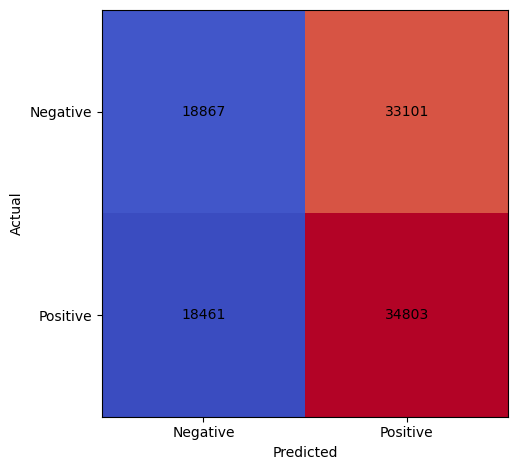

In [ ]:
# let us look at the confusion matrix
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots()

im = ax.imshow(cm, cmap="coolwarm")

ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Negative", "Positive"])
ax.set_yticklabels(["Negative", "Positive"])

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j],
                ha="center",
                va="center")

plt.tight_layout()
plt.show()

A damning confusion matrix if I ever saw one.

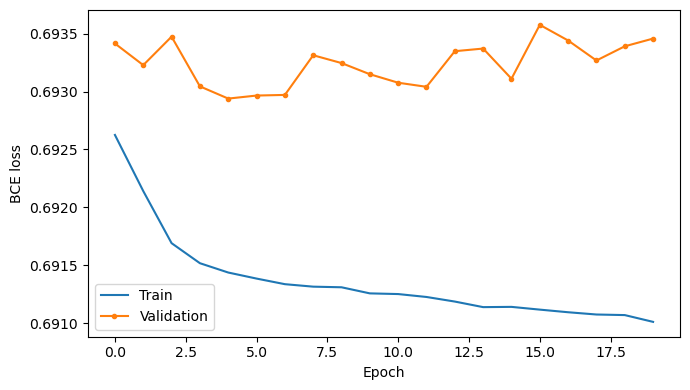

In [56]:
plt.figure(figsize=(7, 4))

plt.plot(train_loss_history, label="Train")
plt.plot(val_loss_history, '.-', label="Validation")

plt.xlabel("Epoch")
plt.ylabel("BCE loss")
plt.legend()
plt.tight_layout()
plt.show()

Confirmed, whilst the train BCE loss slighlty decreases the validation one just hops around. The CNN on this single fold is essentially not predicting out-of-sample signs. It is barely better than a coin toss. We knew the edge was small. But at this stage the HBM clearly stands on top. 

Time to move on to more folds and double check.

In [ ]:
def train_one_fold(k, n_epochs=20, batch_size=256, lr=1e-3):

    # Data
    X_tr = torch.tensor(cnn_folds[k]["X_train"],dtype=torch.float32).unsqueeze(1)
    X_va = torch.tensor(cnn_folds[k]["X_val"],dtype=torch.float32).unsqueeze(1)

    # From a numerical target to a sign classification
    y_tr = torch.tensor(cnn_folds[k]["y_train"],dtype=torch.float32)
    y_va = torch.tensor(cnn_folds[k]["y_val"],dtype=torch.float32)
    y_tr = (y_tr > 0).float()
    y_va = (y_va > 0).float()

    # Data loaders
    train_loader = DataLoader(TensorDataset(X_tr, y_tr),batch_size=batch_size,shuffle=True)
    val_loader = DataLoader(TensorDataset(X_va, y_va),batch_size=batch_size,shuffle=False)

    # Fresh model
    model = ReturnCNN()
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(),lr=lr)

    train_history = []
    val_history = []

    # Training
    for epoch in range(n_epochs):

        model.train()

        total_loss = 0.0
        n = 0

        for xb, yb in train_loader:

            optimizer.zero_grad()

            logits = model(xb)
            loss = criterion(logits, yb)

            loss.backward()
            optimizer.step()

            total_loss += loss.item() * len(yb)
            n += len(yb)

        train_loss = total_loss / n

        # Validation
        model.eval()

        total_loss = 0.0
        n = 0

        with torch.no_grad():

            for xb, yb in val_loader:

                logits = model(xb)
                loss = criterion(logits, yb)

                total_loss += loss.item() * len(yb)
                n += len(yb)

        val_loss = total_loss / n

        train_history.append(train_loss)
        val_history.append(val_loss)

    # Final predictions
    model.eval()

    with torch.no_grad():
        logits = model(X_va)
        probabilities = torch.sigmoid(logits).numpy()

    y_true = y_va.numpy().astype(int)
    y_pred = (probabilities >= 0.5).astype(int)

    # Metrics
    accuracy = accuracy_score(y_true, y_pred)
    balanced_acc = balanced_accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, probabilities)
    cm = confusion_matrix(y_true, y_pred)

    return {
        "model": model,
        "train_loss": train_history,
        "val_loss": val_history,
        "y_true": y_true,
        "y_pred": y_pred,
        "probabilities": probabilities,
        "accuracy": accuracy,
        "balanced_accuracy": balanced_acc,
        "auc": auc,
        "confusion_matrix": cm,
    }

In [58]:
# Run on all five k folds 
results = []
for k in range(len(cnn_folds)):

    print(f"\n========== FOLD {k} ==========")

    result = train_one_fold(k)
    results.append(result)

    print(f"Accuracy:          {result['accuracy']:.4f}")
    print(f"Balanced accuracy: {result['balanced_accuracy']:.4f}")
    print(f"AUC:                {result['auc']:.4f}")

    print("Confusion matrix:")
    print(result["confusion_matrix"])


========== FOLD 0 ==========
Accuracy:          0.5097
Balanced accuracy: 0.5088
AUC:                0.5152
Confusion matrix:
[[22436 29532]
 [22059 31205]]

========== FOLD 1 ==========
Accuracy:          0.5188
Balanced accuracy: 0.5185
AUC:                0.5234
Confusion matrix:
[[25935 25671]
 [24949 28647]]

========== FOLD 2 ==========
Accuracy:          0.5185
Balanced accuracy: 0.5181
AUC:                0.5271
Confusion matrix:
[[25039 27392]
 [23551 29816]]

========== FOLD 3 ==========
Accuracy:          0.5180
Balanced accuracy: 0.5156
AUC:                0.5236
Confusion matrix:
[[20619 31063]
 [19804 34052]]

========== FOLD 4 ==========
Accuracy:          0.5247
Balanced accuracy: 0.5232
AUC:                0.5337
Confusion matrix:
[[20580 31483]
 [18572 34668]]


In [59]:
results_df = pd.DataFrame({
    "fold": range(len(results)),
    "accuracy": [r["accuracy"] for r in results],
    "balanced_accuracy": [r["balanced_accuracy"] for r in results],
    "auc": [r["auc"] for r in results],
})

print(results_df)

print("\nMean:")
print(results_df[["accuracy", "balanced_accuracy", "auc"]].mean())

print("\nStd:")
print(results_df[["accuracy", "balanced_accuracy", "auc"]].std())

   fold  accuracy  balanced_accuracy       auc
0     0  0.509740           0.508791  0.515170
1     1  0.518830           0.518528  0.523442
2     2  0.518488           0.518129  0.527140
3     3  0.518022           0.515619  0.523612
4     4  0.524657           0.523227  0.533675

Mean:
accuracy             0.517948
balanced_accuracy    0.516859
auc                  0.524608
dtype: float64

Std:
accuracy             0.005326
balanced_accuracy    0.005282
auc                  0.006709
dtype: float64


We thus find that the CNN does detect a small out-of-sample directional signal in the 20-day return history. However, the predictive power is small (as expected, always remember how small is the edge). 

Interestingly, compared the "always up strategy" (0.5072), the "sign of yesterday's return approach" (0.5189), the pooled OLS (0.5195), and our HBM (0.5234) it is not looking too hot either. It beats only the first. 

But let us look at what happens if we add also the signed volumes! That might help.

### Volume-aware model inputs

In [74]:
# We treat the signed volumes following our approach used in the HBM pipeline. 

def vol_stats(df):
    stats = {}
    for col in VOL:
        q25, q50, q75 = df[col].quantile([0.25, 0.5, 0.75])

        stats[col] = (q50,(q75 - q25) / 1.349)
    return stats


def prepare_vcnn_data(X, vol_floor, vstats):

    # Row-wise volatility and volatility floor
    s = np.std(X[RET].to_numpy(), axis=1, ddof=1)
    s = np.maximum(s, vol_floor)
    # Normalize each 20-day history and replace the missing returns
    R = np.nan_to_num(X[RET].to_numpy() / s[:, None], nan= 0.0)
    y = X["target"].to_numpy()
    # Signed volumes handling
    V = np.zeros((len(X), len(VOL)), dtype=np.float32)

    for j, col in enumerate(VOL):
        centre, scale = vstats[col]
        z = (X[col] - centre) / scale
        V[:, j] = np.arcsinh(z).fillna(0.0)

    y = X["target"].to_numpy()

    return R, V, y

### Volume-aware CNN

The original vanilla CNN took the 20-day return history as a single temporal sequence. Here, we extend it by adding the signed-volume history as a second input. We use **separate convolutional branches**. This allows the network to learn temporal patterns in returns and volumes independently before learning how the two signals interact.

In particular, each branch consists of two 1D convolutional layers followed by ReLU activations and adaptive average pooling. The resulting 32-dimensional representations are concatenated and passed through a small fully connected head to predict the next-day return sign. It looks like:

$$\text{return history}\rightarrow \text{CNN}_{R}\rightarrow 32\text{-dimensional representation}$$
$$\text{signed-volume history}\rightarrow \text{CNN}_{V}\rightarrow 32\text{-dimensional representation}$$
$$[\text{representation}_R,\text{representation}_V]\rightarrow \text{MLP}\rightarrow P(r_{t+1}>0).$$

In [75]:
# define the model
class ReturnVolumeCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.return_branch = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv1d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.AdaptiveAvgPool1d(1)
        )

        self.volume_branch = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv1d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.AdaptiveAvgPool1d(1)
        )

        self.head = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, r, v):

        r = self.return_branch(r)
        r = r.squeeze(-1)

        v = self.volume_branch(v)
        v = v.squeeze(-1)

        x = torch.cat([r, v], dim=1)

        return self.head(x).squeeze(-1)

In [76]:
cnn_folds = []

for k, (train_idx, val_idx) in enumerate(folds):

    df_train = X_train.iloc[train_idx]
    df_val   = X_train.iloc[val_idx]
    # Return-volatility floor, training fold only
    train_vol = df_train[RET].std(axis=1, ddof=1)
    vol_floor = train_vol.quantile(0.01)
    # Signed-volume statistics, training fold only
    vstats = vol_stats(df_train)

    R_tr, V_tr, y_tr = prepare_vcnn_data(df_train,vol_floor,vstats)
    R_va, V_va, y_va = prepare_vcnn_data(df_val,vol_floor,vstats)

    cnn_folds.append({"R_train": R_tr,"V_train": V_tr,"y_train": y_tr,"R_val": R_va,"V_val": V_va,"y_val": y_va,"vol_floor": vol_floor,"vstats": vstats})

    print(
        f"Fold {k}: "
        f"R_train={R_tr.shape}, "
        f"V_train={V_tr.shape}, "
        f"R_val={R_va.shape}, "
        f"V_val={V_va.shape}, "
        f"vol_floor={vol_floor:.6g}"
    )

Fold 0: R_train=(421841, 20), V_train=(421841, 19), R_val=(105232, 20), V_val=(105232, 19), vol_floor=0.000895856
Fold 1: R_train=(421871, 20), V_train=(421871, 19), R_val=(105202, 20), V_val=(105202, 19), vol_floor=0.000875343
Fold 2: R_train=(421275, 20), V_train=(421275, 19), R_val=(105798, 20), V_val=(105798, 19), vol_floor=0.000894198
Fold 3: R_train=(421535, 20), V_train=(421535, 19), R_val=(105538, 20), V_val=(105538, 19), vol_floor=0.000874752
Fold 4: R_train=(421770, 20), V_train=(421770, 19), R_val=(105303, 20), V_val=(105303, 19), vol_floor=0.000867151


In [77]:
def vtrain_one_fold(k, n_epochs=20, batch_size=256, lr=1e-3):

    # Data
    R_tr, V_tr, R_va, V_va = [torch.tensor(cnn_folds[k][key], dtype=torch.float32).unsqueeze(1) for key in ["R_train", "V_train", "R_val", "V_val"]]
    # From a numerical target to a sign classification
    y_tr = torch.tensor(cnn_folds[k]["y_train"],dtype=torch.float32)
    y_va = torch.tensor(cnn_folds[k]["y_val"],dtype=torch.float32)
    y_tr = (y_tr > 0).float()
    y_va = (y_va > 0).float()
    # tensor data set 
    train_ds = TensorDataset(R_tr, V_tr, y_tr)
    val_ds   = TensorDataset(R_va, V_va, y_va)

    # Data loaders
    train_loader = DataLoader(train_ds,batch_size=batch_size,shuffle=True)
    val_loader = DataLoader(val_ds,batch_size=batch_size,shuffle=False)

    # Model
    model = ReturnVolumeCNN()
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(),lr=lr)

    # Training
    train_history = []
    val_history = []

    for epoch in range(n_epochs):
        model.train()
        total_loss = 0.0
        n = 0
        for  R_batch, V_batch, y_batch in train_loader:
            optimizer.zero_grad()
            logits = model(R_batch,V_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(y_batch)
            n += len(y_batch)
        train_loss = total_loss / n
        # Validation loss
        model.eval()
        total_loss = 0.0
        n = 0
        with torch.no_grad():
            for R_batch, V_batch, y_batch  in val_loader:
                logits = model(R_batch,V_batch)
                loss = criterion(logits, y_batch)
                total_loss += loss.item() * len(yb)
                n += len(y_batch)
        val_loss = total_loss / n
        train_history.append(train_loss)
        val_history.append(val_loss)
    # Validation predictions
    model.eval()
    probabilities = []
    with torch.no_grad():
            for R_batch, V_batch, y_batch in val_loader:
                logits = model(R_batch, V_batch)
                probabilities.append(torch.sigmoid(logits).numpy())

    probabilities = np.concatenate(probabilities)
    y_true = y_va.numpy().astype(int)
    y_pred = (probabilities >= 0.5).astype(int)
    # Metrics
    accuracy = accuracy_score(y_true,y_pred)
    balanced_acc = balanced_accuracy_score(y_true,y_pred)
    auc = roc_auc_score(y_true,probabilities)
    cm = confusion_matrix(y_true,y_pred)

    return {
        "model": model,

        "train_loss": train_history,
        "val_loss": val_history,

        "y_true": y_true,
        "y_pred": y_pred,
        "probabilities": probabilities,

        "accuracy": accuracy,
        "balanced_accuracy": balanced_acc,
        "auc": auc,

        "confusion_matrix": cm,
    }

In [78]:
results = []

for k in range(len(cnn_folds)):

    print(f"\n========== FOLD {k} ==========")

    result = vtrain_one_fold(k)
    results.append(result)

    print(f"Accuracy:          "f"{result['accuracy']:.4f}")

    print(f"Balanced accuracy: "f"{result['balanced_accuracy']:.4f}"
    )

    print(f"AUC:                "f"{result['auc']:.4f}")

    print("Confusion matrix:")
    print(result["confusion_matrix"])


========== FOLD 0 ==========
Accuracy:          0.5099
Balanced accuracy: 0.5100
AUC:                0.5130
Confusion matrix:
[[27061 24907]
 [26667 26597]]

========== FOLD 1 ==========
Accuracy:          0.5165
Balanced accuracy: 0.5151
AUC:                0.5232
Confusion matrix:
[[22789 28817]
 [22045 31551]]

========== FOLD 2 ==========
Accuracy:          0.5185
Balanced accuracy: 0.5179
AUC:                0.5262
Confusion matrix:
[[23377 29054]
 [21887 31480]]

========== FOLD 3 ==========
Accuracy:          0.5193
Balanced accuracy: 0.5166
AUC:                0.5249
Confusion matrix:
[[19685 31997]
 [18730 35126]]

========== FOLD 4 ==========
Accuracy:          0.5219
Balanced accuracy: 0.5198
AUC:                0.5305
Confusion matrix:
[[17446 34617]
 [15728 37512]]


In [79]:
results_df = pd.DataFrame({
    "fold": range(len(results)),
    "accuracy": [r["accuracy"] for r in results],
    "balanced_accuracy": [r["balanced_accuracy"] for r in results],
    "auc": [r["auc"] for r in results],
})

print(results_df.to_string(index=False))

print("\nMean:")
print(results_df[["accuracy", "balanced_accuracy", "auc"]].mean())

print("\nStd:")
print(results_df[["accuracy", "balanced_accuracy", "auc"]].std())

 fold  accuracy  balanced_accuracy      auc
    0  0.509902           0.510034 0.512962
    1  0.516530           0.515139 0.523213
    2  0.518507           0.517870 0.526214
    3  0.519348           0.516554 0.524929
    4  0.521903           0.519839 0.530463

Mean:
accuracy             0.517238
balanced_accuracy    0.515887
auc                  0.523556
dtype: float64

Std:
accuracy             0.004532
balanced_accuracy    0.003702
auc                  0.006500
dtype: float64


So we find $z \approx - 0.23$ with respect to the other CNN. Just like with the HBM adding volume seems to make this slighlty worse. Here "seems" is important. That could just have been a fluke, given the value.

But we are not done yet. We are going to (i) remove the global average pooling (this discards information about where in the 20-day history a feature occured, we might want that actually...), (ii) add multiple kernel sizes in parallel to detect different temporal scales, and (iii) increase the depth with residual blocks to pool on hierarchical temporal information.

### Retaining the lag

We remove the global pooling and flatten the convolutional representation. The convolutional branches still learn local temporal features, but the final MLP receives the full sequence of learned features. Thus, now it will be able to differentiate between a pattern occurring at a recent lag from the same pattern occurring further back in the history.

The architecture is therefore

$$\text{return history}\rightarrow\mathrm{CNN}_R\rightarrow\mathrm{Flatten},$$
$$\text{volume history}\rightarrow\mathrm{CNN}_V\rightarrow\mathrm{Flatten},$$

followed by concatenation and a small fully connected head.



In [80]:
class ReturnVolumeCNNNoPool(nn.Module):
    def __init__(self):
        super().__init__()

        self.return_branch = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv1d(16, 32, kernel_size=3, padding=1),
            nn.ReLU()
        )

        self.volume_branch = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv1d(16, 32, kernel_size=3, padding=1),
            nn.ReLU()
        )

        # 32 features × 20 return lags
        # 32 features × 19 volume lags
        self.head = nn.Sequential(
            nn.Linear(32 * 20 + 32 * 19, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, r, v):

        r = self.return_branch(r)
        r = r.flatten(start_dim=1)

        v = self.volume_branch(v)
        v = v.flatten(start_dim=1)

        x = torch.cat([r, v], dim=1)

        return self.head(x).squeeze(-1)

In [81]:
def vtrain_nopool_one_fold(k, n_epochs=20, batch_size=256, lr=1e-3):

    # Data
    R_tr, V_tr, R_va, V_va = [torch.tensor(cnn_folds[k][key],dtype=torch.float32).unsqueeze(1)for key in ["R_train", "V_train", "R_val", "V_val"]]

    # Target
    y_tr = torch.tensor(cnn_folds[k]["y_train"],dtype=torch.float32)
    y_va = torch.tensor(cnn_folds[k]["y_val"],dtype=torch.float32)
    y_tr = (y_tr > 0).float()
    y_va = (y_va > 0).float()

    # Tensor datasets
    train_ds = TensorDataset(R_tr, V_tr, y_tr)
    val_ds   = TensorDataset(R_va, V_va, y_va)

    # Data loaders
    train_loader = DataLoader(train_ds,batch_size=batch_size,shuffle=True)
    val_loader = DataLoader(val_ds,batch_size=batch_size,shuffle=False)

    # Model
    model = ReturnVolumeCNNNoPool()
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(),lr=lr)

    # Training history
    train_history = []
    val_history = []

    for epoch in range(n_epochs):
        # Training
        model.train()
        total_loss = 0.0
        n = 0
        for R_batch, V_batch, y_batch in train_loader:
            optimizer.zero_grad()
            logits = model(R_batch, V_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(y_batch)
            n += len(y_batch)
        train_loss = total_loss / n
        # Validation loss
        model.eval()
        total_loss = 0.0
        n = 0
        with torch.no_grad():
            for R_batch, V_batch, y_batch in val_loader:
                logits = model(R_batch, V_batch)
                loss = criterion(logits, y_batch)
                total_loss += loss.item() * len(y_batch)
                n += len(y_batch)
        val_loss = total_loss / n
        train_history.append(train_loss)
        val_history.append(val_loss)
    # Validation predictions
    model.eval()
    probabilities = []
    with torch.no_grad():
        for R_batch, V_batch, y_batch in val_loader:
            logits = model(R_batch, V_batch)
            probabilities.append(torch.sigmoid(logits).numpy())

    probabilities = np.concatenate(probabilities)
    y_true = y_va.numpy().astype(int)
    y_pred = (probabilities >= 0.5).astype(int)
    # Metrics
    accuracy = accuracy_score(y_true, y_pred)
    balanced_acc = balanced_accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, probabilities)
    cm = confusion_matrix(y_true, y_pred)

    return {
        "model": model,

        "train_loss": train_history,
        "val_loss": val_history,

        "y_true": y_true,
        "y_pred": y_pred,
        "probabilities": probabilities,

        "accuracy": accuracy,
        "balanced_accuracy": balanced_acc,
        "auc": auc,

        "confusion_matrix": cm,
    }

In [ ]:
nopool_results = []
for k in range(len(cnn_folds)):
    result = vtrain_nopool_one_fold(k)
    nopool_results.append(result)
    print(
        f"Fold {k}: "
        f"accuracy={result['accuracy']:.6f}, "
        f"balanced accuracy={result['balanced_accuracy']:.6f}, "
        f"AUC={result['auc']:.6f}"
    )

In [ ]:
acc = np.array([r["accuracy"] for r in nopool_results])
bacc = np.array([r["balanced_accuracy"] for r in nopool_results])
auc = np.array([r["auc"] for r in nopool_results])

print("\nMean:")
print(pd.Series({"accuracy": acc.mean(),"balanced_accuracy": bacc.mean(),"auc": auc.mean()}))

print("\nStd:")
print(pd.Series({"accuracy": acc.std(ddof=1),"balanced_accuracy": bacc.std(ddof=1),"auc": auc.std(ddof=1)}))

In [ ]:
# Checking as here overfitting might quite easily happen
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(result["train_loss"]) + 1),result["train_loss"],label="Training")
plt.plot(range(1, len(result["val_loss"]) + 1),result["val_loss"],label="Validation")
plt.xlabel("Epoch")
plt.ylabel("BCE loss")
plt.legend()
plt.tight_layout()
plt.show()